In [1]:
# ============================================================
# STEP 1: LOAD AND EXPLORE THE DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/data.csv')

# Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Basic overview
print("Shape of data:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape of data: (1051, 28)

Column names:
['date', 'station', 'PM2.5', 'PM10', 'wind_speed', 'wind_dir', 'humidity', 'temperature', 'rainfall', 'NO2', 'NH3', 'CO', 'SO2', 'month', 'day_of_week', 'season', 'PM2.5_lag1', 'PM2.5_lag2', 'PM2.5_lag3', 'PM10_lag1', 'PM10_lag3', 'wind_speed_lag1', 'humidity_lag1', 'PM2.5_roll7', 'PM10_roll7', 'wind_roll3', 'humidity_roll3', 'station_code']

First 5 rows:


,date,station,PM2.5,PM10,wind_speed,wind_dir,humidity,temperature,rainfall,NO2,...,PM2.5_lag3,PM10_lag1,PM10_lag3,wind_speed_lag1,humidity_lag1,PM2.5_roll7,PM10_roll7,wind_roll3,humidity_roll3,station_code
0,2019-01-04,"MIDC Khutala, Chandrapur - MPCB",49.03,102.07,0.76,143.98,61.80,21.95,0.0,48.30,...,46.78,115.85,116.51,0.61,65.21,44.786667,110.983333,0.556667,62.566667,0
1,2019-01-05,"MIDC Khutala, Chandrapur - MPCB",46.59,99.33,0.80,127.78,65.44,21.82,0.0,54.48,...,41.60,102.07,100.59,0.76,61.80,45.847500,108.755000,0.653333,62.863333,0
2,2019-01-06,"MIDC Khutala, Chandrapur - MPCB",43.70,85.84,0.87,133.85,72.01,22.28,0.0,53.00,...,45.98,99.33,115.85,0.80,65.44,45.996000,106.870000,0.723333,64.150000,0
3,2019-01-07,"MIDC Khutala, Chandrapur - MPCB",51.55,117.27,1.23,184.60,75.44,22.02,0.0,52.04,...,49.03,85.84,102.07,0.87,72.01,45.613333,103.365000,0.810000,66.416667,0
4,2019-01-08,"MIDC Khutala, Chandrapur - MPCB",44.51,99.35,0.67,206.33,62.20,19.49,0.0,45.39,...,46.59,117.27,99.33,1.23,75.44,46.461429,105.351429,0.966667,70.963333,0


In [2]:
# Check missing values and data types
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Basic Statistics ===")
df.describe().round(2)

=== Missing Values ===
date               0
station            0
PM2.5              0
PM10               0
wind_speed         0
wind_dir           0
humidity           0
temperature        0
rainfall           0
NO2                0
NH3                0
CO                 0
SO2                0
month              0
day_of_week        0
season             0
PM2.5_lag1         0
PM2.5_lag2         0
PM2.5_lag3         0
PM10_lag1          0
PM10_lag3          0
wind_speed_lag1    0
humidity_lag1      0
PM2.5_roll7        0
PM10_roll7         0
wind_roll3         0
humidity_roll3     0
station_code       0
dtype: int64

=== Data Types ===
date               datetime64[ns]
station                    object
PM2.5                     float64
PM10                      float64
wind_speed                float64
wind_dir                  float64
humidity                  float64
temperature               float64
rainfall                  float64
NO2                       float64
NH3             

,date,PM2.5,PM10,wind_speed,wind_dir,humidity,temperature,rainfall,NO2,NH3,...,PM2.5_lag3,PM10_lag1,PM10_lag3,wind_speed_lag1,humidity_lag1,PM2.5_roll7,PM10_roll7,wind_roll3,humidity_roll3,station_code
count,1051,1051.00,1051.00,1051.00,1051.00,1051.00,1051.00,1051.00,1051.00,1051.00,...,1051.00,1051.00,1051.00,1051.00,1051.00,1051.00,1051.00,1051.00,1051.00,1051.00
mean,2019-07-01 02:19:45.156993280,54.63,149.06,6.71,185.38,65.88,26.65,3.23,24.95,14.19,...,54.64,149.18,149.42,6.71,65.83,54.72,149.68,6.71,65.81,1.02
min,2019-01-04 00:00:00,1.00,12.78,0.47,2.00,16.00,10.00,0.00,0.03,0.11,...,1.00,12.78,12.78,0.47,16.00,1.96,18.60,0.51,16.00,0.00
25%,2019-04-01 00:00:00,24.34,63.21,1.80,140.38,55.06,23.50,0.00,7.18,7.51,...,24.34,63.21,63.21,1.80,55.06,25.58,69.54,1.78,56.07,0.00
50%,2019-06-29 00:00:00,41.00,104.89,2.74,178.04,70.77,26.97,0.00,9.54,12.87,...,41.17,104.93,105.02,2.74,70.76,42.28,105.29,2.76,70.65,1.00
75%,2019-10-01 00:00:00,74.76,224.88,11.30,225.50,80.63,29.90,0.65,36.86,15.73,...,74.76,224.88,224.88,11.35,80.60,77.23,236.84,11.82,80.33,2.00
max,2019-12-31 00:00:00,259.06,652.06,31.80,359.00,98.62,38.21,100.50,225.01,246.51,...,267.76,652.06,652.06,31.80,98.62,221.50,431.58,26.43,95.13,2.00
std,NaN,42.52,111.45,7.06,77.25,19.49,5.12,9.79,29.62,12.85,...,42.54,111.64,112.03,7.06,19.47,39.54,101.45,6.80,18.94,0.82


In [3]:
# How many records from each station?
print("Records per station:")
print(df['station'].value_counts())

Records per station:
station
Vindhyachal STPS, Singrauli - MPPCB    362
Talcher Coalfields,Talcher - OSPCB     347
MIDC Khutala, Chandrapur - MPCB        342
Name: count, dtype: int64


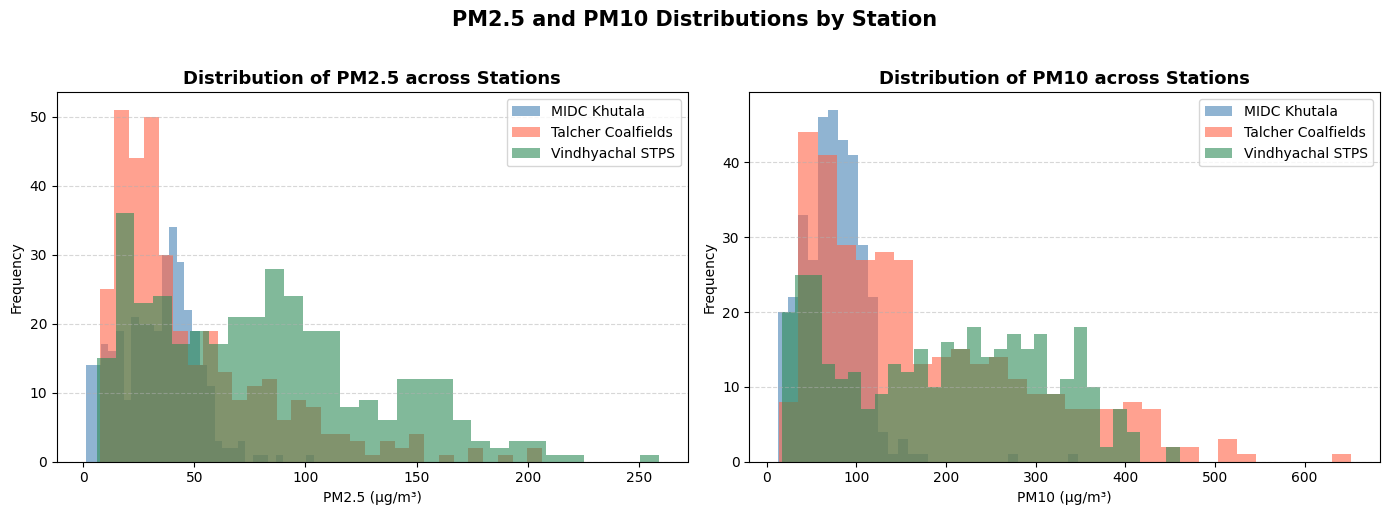

✅ Plot saved!


In [4]:
# ============================================================
# STEP 2A: PM2.5 and PM10 distribution by station
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stations = df['station'].unique()
colors = ['steelblue', 'tomato', 'seagreen']

for ax, pollutant in zip(axes, ['PM2.5', 'PM10']):
    for i, station in enumerate(stations):
        data = df[df['station'] == station][pollutant]
        ax.hist(data, bins=30, alpha=0.6, color=colors[i], label=station.split(',')[0])
    ax.set_title(f'Distribution of {pollutant} across Stations', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{pollutant} (µg/m³)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('PM2.5 and PM10 Distributions by Station', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

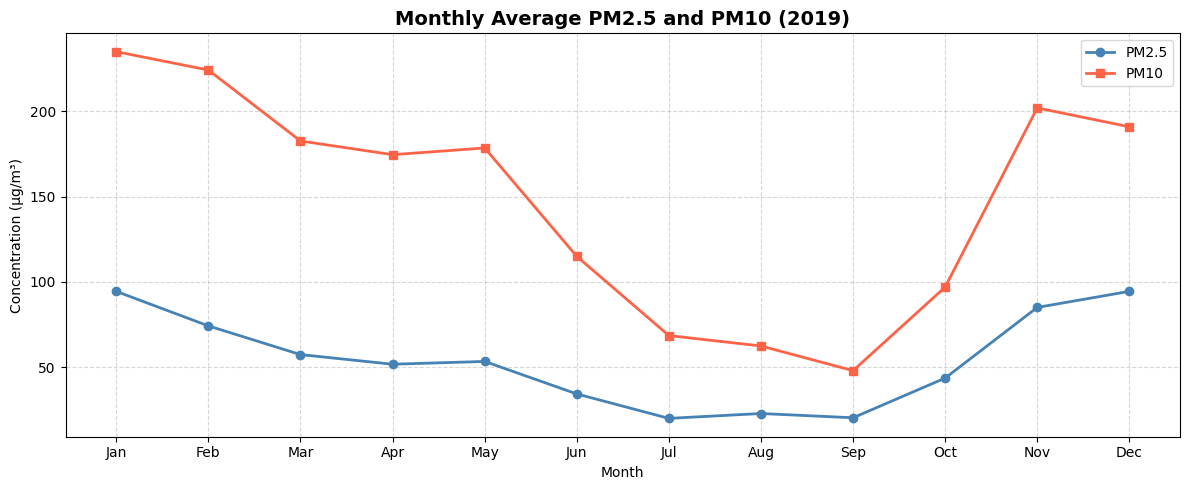

✅ Plot saved!


In [5]:
# ============================================================
# STEP 2B: Monthly average PM2.5 and PM10 trend
# ============================================================

monthly = df.groupby('month')[['PM2.5', 'PM10']].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['month'], monthly['PM2.5'], marker='o', color='steelblue', linewidth=2, label='PM2.5')
ax.plot(monthly['month'], monthly['PM10'], marker='s', color='tomato', linewidth=2, label='PM10')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Monthly Average PM2.5 and PM10 (2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Concentration (µg/m³)')
ax.legend()
ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

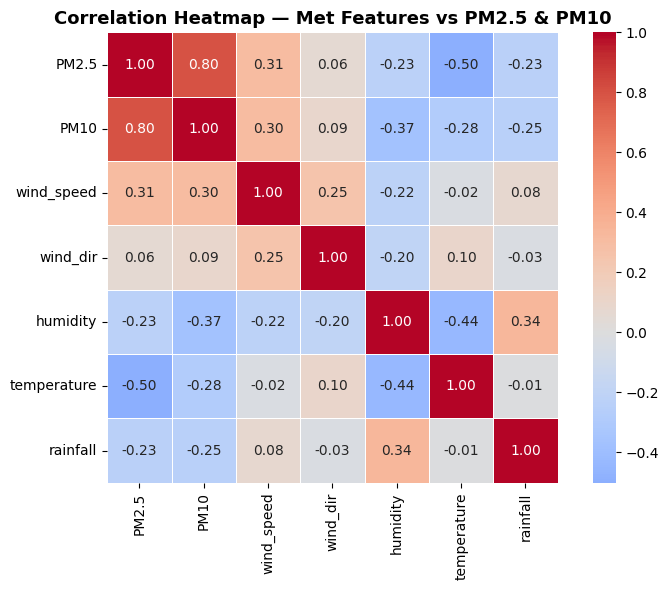

✅ Plot saved!


In [6]:
# ============================================================
# STEP 2C: Correlation heatmap - Meteorological features vs PM
# ============================================================

met_cols = ['PM2.5', 'PM10', 'wind_speed', 'wind_dir', 'humidity', 'temperature', 'rainfall']

corr = df[met_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Met Features vs PM2.5 & PM10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_heatmap_met.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

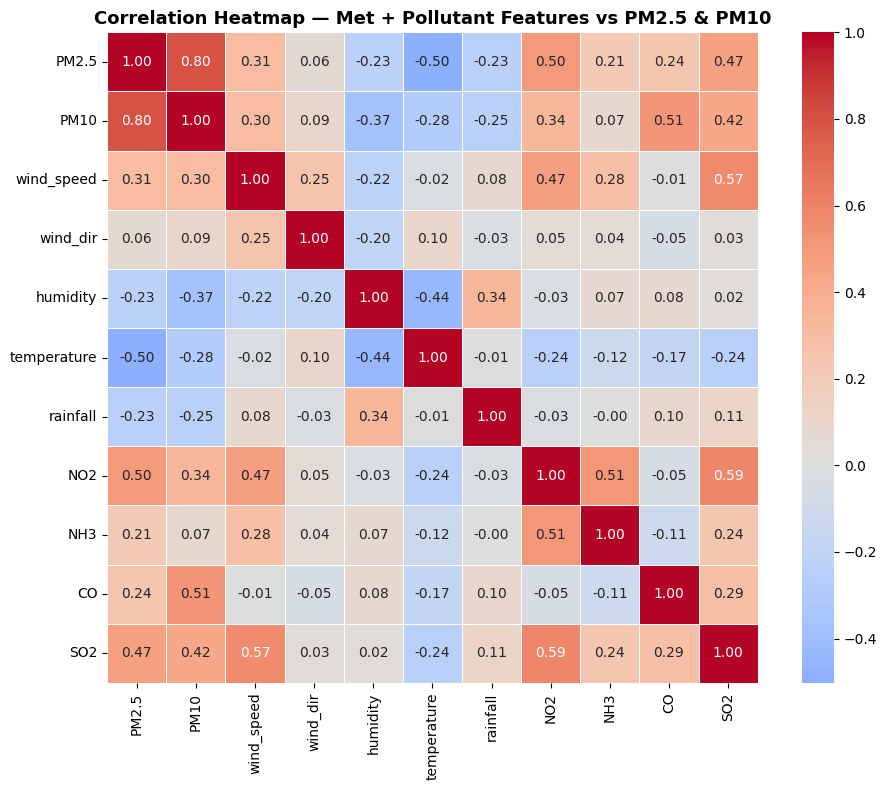

✅ Plot saved!


In [7]:
# ============================================================
# STEP 2D: Correlation heatmap - Met + Pollutant features vs PM
# ============================================================

all_cols = ['PM2.5', 'PM10', 'wind_speed', 'wind_dir', 'humidity',
            'temperature', 'rainfall', 'NO2', 'NH3', 'CO', 'SO2']

corr2 = df[all_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Met + Pollutant Features vs PM2.5 & PM10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_heatmap_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

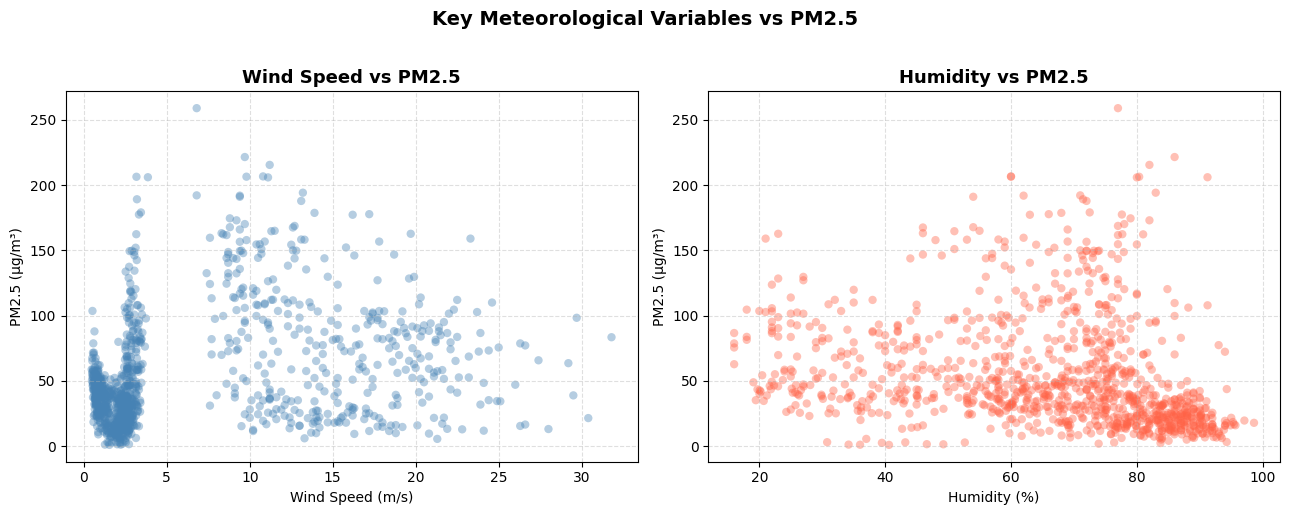

✅ Plot saved!


In [8]:
# ============================================================
# STEP 2E: Scatter plots - key met variables vs PM2.5
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['wind_speed'], df['PM2.5'], alpha=0.4, color='steelblue', edgecolors='none')
axes[0].set_title('Wind Speed vs PM2.5', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Wind Speed (m/s)')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].grid(linestyle='--', alpha=0.4)

axes[1].scatter(df['humidity'], df['PM2.5'], alpha=0.4, color='tomato', edgecolors='none')
axes[1].set_title('Humidity vs PM2.5', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Humidity (%)')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('Key Meteorological Variables vs PM2.5', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot5_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [9]:
# ============================================================
# STEP 3: CREATE NEXT-DAY PREDICTION TARGET
# ============================================================

# Sort data properly - very important!
df = df.sort_values(['station', 'date']).reset_index(drop=True)

# Create next-day PM2.5 and PM10 targets
# shift(-1) means: "take tomorrow's value and put it in today's row"
df['PM2.5_next_day'] = df.groupby('station')['PM2.5'].shift(-1)
df['PM10_next_day']  = df.groupby('station')['PM10'].shift(-1)

# The last row of each station will have NaN (no tomorrow) — drop those
df = df.dropna(subset=['PM2.5_next_day', 'PM10_next_day'])

print("Data shape after creating targets:", df.shape)
print("\nSample — Today's PM2.5 vs Next Day's PM2.5:")
df[['date', 'station', 'PM2.5', 'PM2.5_next_day', 'PM10', 'PM10_next_day']].head(8)

Data shape after creating targets: (1048, 30)

Sample — Today's PM2.5 vs Next Day's PM2.5:


,date,station,PM2.5,PM2.5_next_day,PM10,PM10_next_day
0,2019-01-04,"MIDC Khutala, Chandrapur - MPCB",49.03,46.59,102.07,99.33
1,2019-01-05,"MIDC Khutala, Chandrapur - MPCB",46.59,43.70,99.33,85.84
2,2019-01-06,"MIDC Khutala, Chandrapur - MPCB",43.70,51.55,85.84,117.27
3,2019-01-07,"MIDC Khutala, Chandrapur - MPCB",51.55,44.51,117.27,99.35
4,2019-01-08,"MIDC Khutala, Chandrapur - MPCB",44.51,43.90,99.35,86.07
5,2019-01-09,"MIDC Khutala, Chandrapur - MPCB",43.90,38.54,86.07,94.05
6,2019-01-10,"MIDC Khutala, Chandrapur - MPCB",38.54,38.97,94.05,89.66
7,2019-01-11,"MIDC Khutala, Chandrapur - MPCB",38.97,37.85,89.66,88.30


In [10]:
# ============================================================
# STEP 3B: DEFINE FEATURE SETS
# ============================================================

# Model A: Meteorological features ONLY
met_features = [
    'wind_speed', 'wind_dir', 'humidity', 'temperature', 'rainfall',
    'month', 'season'
]

# Model B: Meteorological + Pollutant features
met_poll_features = [
    'wind_speed', 'wind_dir', 'humidity', 'temperature', 'rainfall',
    'NO2', 'NH3', 'CO', 'SO2',
    'month', 'season'
]

# Our targets
target_pm25 = 'PM2.5_next_day'
target_pm10 = 'PM10_next_day'

print("Model A features (Met only):", met_features)
print("\nModel B features (Met + Pollutants):", met_poll_features)
print("\nTargets: PM2.5_next_day and PM10_next_day")

Model A features (Met only): ['wind_speed', 'wind_dir', 'humidity', 'temperature', 'rainfall', 'month', 'season']

Model B features (Met + Pollutants): ['wind_speed', 'wind_dir', 'humidity', 'temperature', 'rainfall', 'NO2', 'NH3', 'CO', 'SO2', 'month', 'season']

Targets: PM2.5_next_day and PM10_next_day


In [11]:
# ============================================================
# STEP 3C: TRAIN-TEST SPLIT (80% train, 20% test)
# ============================================================

from sklearn.model_selection import train_test_split

# We use random_state=42 so results are same every time you run
X_A = df[met_features]           # Model A inputs
X_B = df[met_poll_features]      # Model B inputs

y_25 = df[target_pm25]           # Target: next-day PM2.5
y_10 = df[target_pm10]           # Target: next-day PM10

# Split — same split for all models so comparison is fair
X_A_train, X_A_test, y25_train, y25_test = train_test_split(X_A, y_25, test_size=0.2, random_state=42)
X_B_train, X_B_test, _,         _        = train_test_split(X_B, y_25, test_size=0.2, random_state=42)

# For PM10
X_A_train10, X_A_test10, y10_train, y10_test = train_test_split(X_A, y_10, test_size=0.2, random_state=42)
X_B_train10, X_B_test10, _,         _         = train_test_split(X_B, y_10, test_size=0.2, random_state=42)

print(f"Training samples : {len(X_A_train)}")
print(f"Testing samples  : {len(X_A_test)}")
print("\n✅ Train-test split done! Ready for model building.")

Training samples : 838
Testing samples  : 210

✅ Train-test split done! Ready for model building.


In [12]:
# ============================================================
# STEP 4: MULTIPLE LINEAR REGRESSION (MLR)
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Helper function to print results nicely
def evaluate_model(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"  R²   = {r2:.4f}   (closer to 1.0 = better)")
    print(f"  MAE  = {mae:.2f}  (average error in µg/m³)")
    print(f"  RMSE = {rmse:.2f} (penalizes large errors)")
    return r2, mae, rmse

# ---- PM2.5 ----
print("=" * 50)
print("TARGET: Next-Day PM2.5")
print("=" * 50)

# Model A: Met only
lr_A_25 = LinearRegression()
lr_A_25.fit(X_A_train, y25_train)
pred_A_25 = lr_A_25.predict(X_A_test)
print("\n📌 Model A — MLR (Met Only):")
r2_A25, mae_A25, rmse_A25 = evaluate_model("A-PM2.5", y25_test, pred_A_25)

# Model B: Met + Pollutants
lr_B_25 = LinearRegression()
lr_B_25.fit(X_B_train, y25_train)
pred_B_25 = lr_B_25.predict(X_B_test)
print("\n📌 Model B — MLR (Met + Pollutants):")
r2_B25, mae_B25, rmse_B25 = evaluate_model("B-PM2.5", y25_test, pred_B_25)

# ---- PM10 ----
print("\n" + "=" * 50)
print("TARGET: Next-Day PM10")
print("=" * 50)

# Model A: Met only
lr_A_10 = LinearRegression()
lr_A_10.fit(X_A_train10, y10_train)
pred_A_10 = lr_A_10.predict(X_A_test10)
print("\n📌 Model A — MLR (Met Only):")
r2_A10, mae_A10, rmse_A10 = evaluate_model("A-PM10", y10_test, pred_A_10)

# Model B: Met + Pollutants
lr_B_10 = LinearRegression()
lr_B_10.fit(X_B_train10, y10_train)
pred_B_10 = lr_B_10.predict(X_B_test10)
print("\n📌 Model B — MLR (Met + Pollutants):")
r2_B10, mae_B10, rmse_B10 = evaluate_model("B-PM10", y10_test, pred_B_10)

TARGET: Next-Day PM2.5

📌 Model A — MLR (Met Only):
  R²   = 0.6108   (closer to 1.0 = better)
  MAE  = 18.15  (average error in µg/m³)
  RMSE = 24.73 (penalizes large errors)

📌 Model B — MLR (Met + Pollutants):
  R²   = 0.6384   (closer to 1.0 = better)
  MAE  = 17.75  (average error in µg/m³)
  RMSE = 23.84 (penalizes large errors)

TARGET: Next-Day PM10

📌 Model A — MLR (Met Only):
  R²   = 0.3628   (closer to 1.0 = better)
  MAE  = 62.56  (average error in µg/m³)
  RMSE = 83.12 (penalizes large errors)

📌 Model B — MLR (Met + Pollutants):
  R²   = 0.5665   (closer to 1.0 = better)
  MAE  = 51.67  (average error in µg/m³)
  RMSE = 68.56 (penalizes large errors)


In [13]:
# ============================================================
# STEP 4B: LOOK AT REGRESSION COEFFICIENTS
# (Which features affect PM the most?)
# ============================================================

print("=" * 55)
print("MLR Coefficients — Model A (Met Only) → PM2.5")
print("=" * 55)
coef_A = pd.DataFrame({
    'Feature'    : met_features,
    'Coefficient': lr_A_25.coef_.round(4)
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_A.to_string(index=False))

print("\n" + "=" * 55)
print("MLR Coefficients — Model B (Met+Poll) → PM2.5")
print("=" * 55)
coef_B = pd.DataFrame({
    'Feature'    : met_poll_features,
    'Coefficient': lr_B_25.coef_.round(4)
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_B.to_string(index=False))

MLR Coefficients — Model A (Met Only) → PM2.5
    Feature  Coefficient
temperature      -6.2179
      month       2.7519
   humidity      -1.3126
 wind_speed       1.0783
     season       0.3888
   rainfall      -0.3692
   wind_dir       0.0215

MLR Coefficients — Model B (Met+Poll) → PM2.5
    Feature  Coefficient
         CO      10.1353
temperature      -5.1234
      month       2.6235
     season      -1.3647
   humidity      -1.2118
   rainfall      -0.4186
        NO2       0.2966
 wind_speed       0.2615
        SO2       0.1698
        NH3       0.0532
   wind_dir       0.0321


In [20]:
# ============================================================
# MLR Coefficients for PM10 — Model A and Model B
# ============================================================

print("=" * 55)
print("MLR Coefficients — Model A (Met Only) → PM10")
print("=" * 55)
coef_A10 = pd.DataFrame({
    'Feature'    : met_features,
    'Coefficient': lr_A_10.coef_.round(4)
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_A10.to_string(index=False))

print("\n" + "=" * 55)
print("MLR Coefficients — Model B (Met+Poll) → PM10")
print("=" * 55)
coef_B10 = pd.DataFrame({
    'Feature'    : met_poll_features,
    'Coefficient': lr_B_10.coef_.round(4)
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_B10.to_string(index=False))

MLR Coefficients — Model A (Met Only) → PM10
    Feature  Coefficient
temperature     -11.3304
   humidity      -2.9804
 wind_speed       2.8961
     season       1.4455
   rainfall      -1.1381
      month       0.6842
   wind_dir       0.0949

MLR Coefficients — Model B (Met+Poll) → PM10
    Feature  Coefficient
         CO      73.4083
temperature      -8.5226
      month       3.4918
   humidity      -3.0366
 wind_speed       1.9315
   rainfall      -1.5861
        NO2       0.5415
   wind_dir       0.1267
        NH3      -0.1163
        SO2       0.0750
     season       0.0256


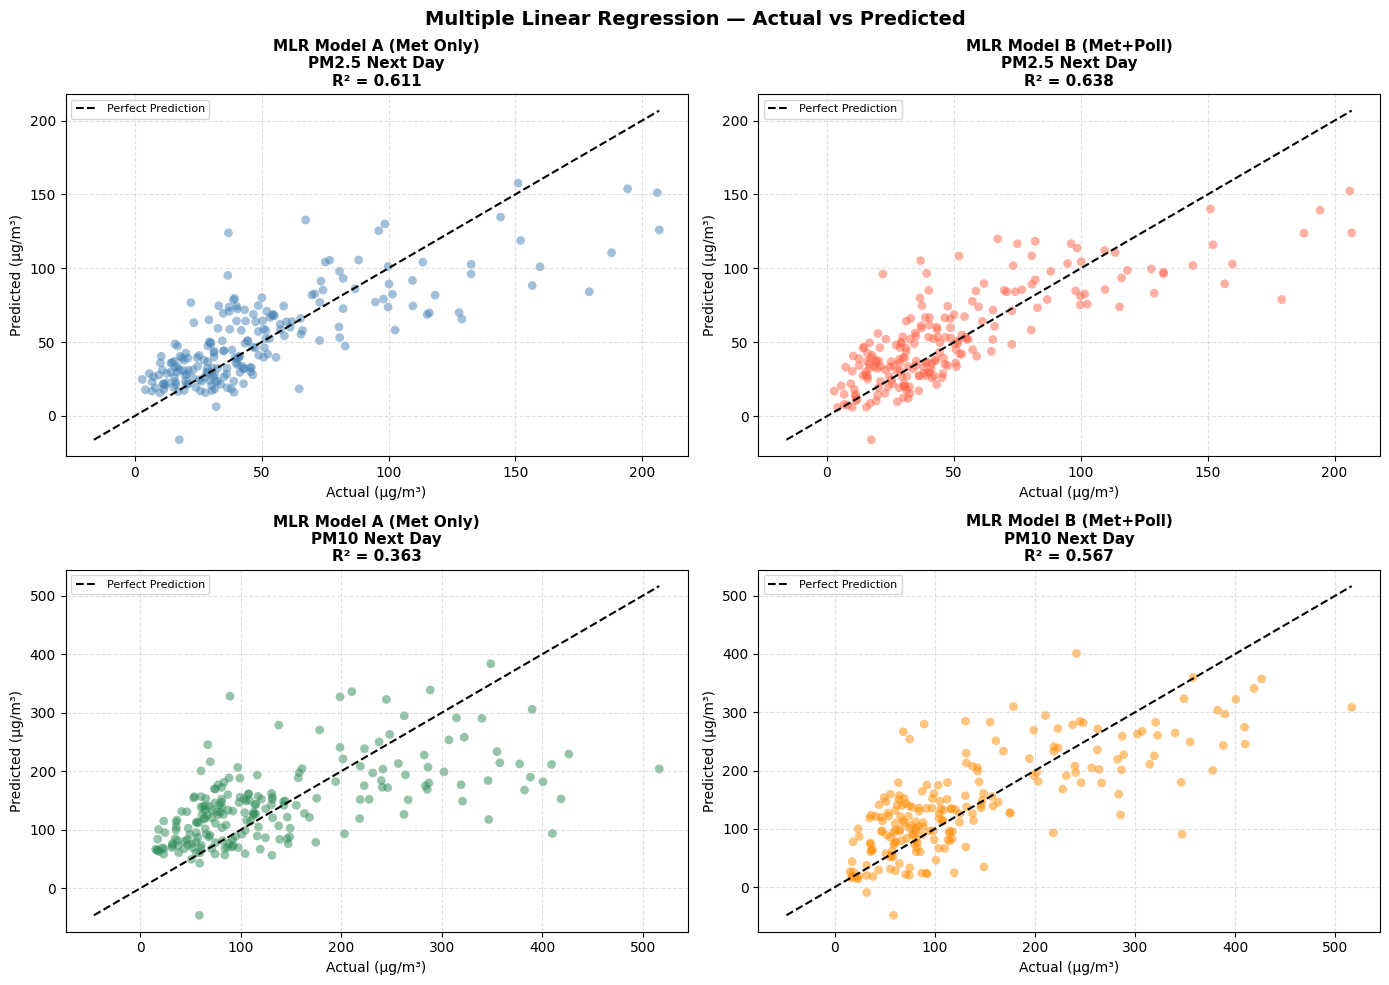

✅ Plot saved!


In [14]:
# ============================================================
# STEP 4C: ACTUAL vs PREDICTED PLOTS — MLR
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_data = [
    (axes[0,0], y25_test, pred_A_25, "MLR Model A (Met Only)\nPM2.5 Next Day",      "steelblue"),
    (axes[0,1], y25_test, pred_B_25, "MLR Model B (Met+Poll)\nPM2.5 Next Day",      "tomato"),
    (axes[1,0], y10_test, pred_A_10, "MLR Model A (Met Only)\nPM10 Next Day",       "seagreen"),
    (axes[1,1], y10_test, pred_B_10, "MLR Model B (Met+Poll)\nPM10 Next Day",       "darkorange"),
]

for ax, y_true, y_pred, title, color in plot_data:
    ax.scatter(y_true, y_pred, alpha=0.5, color=color, edgecolors='none', s=40)
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect Prediction')
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f"{title}\nR² = {r2:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Actual (µg/m³)")
    ax.set_ylabel("Predicted (µg/m³)")
    ax.legend(fontsize=8)
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle("Multiple Linear Regression — Actual vs Predicted", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_mlr_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [15]:
# ============================================================
# STEP 5: RANDOM FOREST + GRADIENT BOOSTING
# ============================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ---- RANDOM FOREST ----
# n_estimators = 100 trees working together and voting
# random_state = 42 so results are same every time

rf_A_25 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_A_25.fit(X_A_train, y25_train)
pred_rf_A_25 = rf_A_25.predict(X_A_test)

rf_B_25 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_B_25.fit(X_B_train, y25_train)
pred_rf_B_25 = rf_B_25.predict(X_B_test)

rf_A_10 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_A_10.fit(X_A_train10, y10_train)
pred_rf_A_10 = rf_A_10.predict(X_A_test10)

rf_B_10 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_B_10.fit(X_B_train10, y10_train)
pred_rf_B_10 = rf_B_10.predict(X_B_test10)

# ---- GRADIENT BOOSTING ----
# Builds trees one by one, each one fixing the errors of the previous

gb_A_25 = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_A_25.fit(X_A_train, y25_train)
pred_gb_A_25 = gb_A_25.predict(X_A_test)

gb_B_25 = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_B_25.fit(X_B_train, y25_train)
pred_gb_B_25 = gb_B_25.predict(X_B_test)

gb_A_10 = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_A_10.fit(X_A_train10, y10_train)
pred_gb_A_10 = gb_A_10.predict(X_A_test10)

gb_B_10 = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_B_10.fit(X_B_train10, y10_train)
pred_gb_B_10 = gb_B_10.predict(X_B_test10)

print("✅ All models trained successfully!")

✅ All models trained successfully!


In [16]:
# ============================================================
# STEP 5B: FULL RESULTS COMPARISON TABLE
# ============================================================

results = []

combos = [
    # (model_name, feature_set, target, y_true, y_pred)
    ("MLR",                "Met Only",      "PM2.5", y25_test, pred_A_25),
    ("MLR",                "Met+Pollutants","PM2.5", y25_test, pred_B_25),
    ("Random Forest",      "Met Only",      "PM2.5", y25_test, pred_rf_A_25),
    ("Random Forest",      "Met+Pollutants","PM2.5", y25_test, pred_rf_B_25),
    ("Gradient Boosting",  "Met Only",      "PM2.5", y25_test, pred_gb_A_25),
    ("Gradient Boosting",  "Met+Pollutants","PM2.5", y25_test, pred_gb_B_25),

    ("MLR",                "Met Only",      "PM10",  y10_test, pred_A_10),
    ("MLR",                "Met+Pollutants","PM10",  y10_test, pred_B_10),
    ("Random Forest",      "Met Only",      "PM10",  y10_test, pred_rf_A_10),
    ("Random Forest",      "Met+Pollutants","PM10",  y10_test, pred_rf_B_10),
    ("Gradient Boosting",  "Met Only",      "PM10",  y10_test, pred_gb_A_10),
    ("Gradient Boosting",  "Met+Pollutants","PM10",  y10_test, pred_gb_B_10),
]

for model, features, target, y_true, y_pred in combos:
    results.append({
        'Model'       : model,
        'Features'    : features,
        'Target'      : target,
        'R²'          : round(r2_score(y_true, y_pred), 4),
        'MAE'         : round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE'        : round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
    })

results_df = pd.DataFrame(results)

print("=" * 70)
print("COMPLETE MODEL COMPARISON TABLE")
print("=" * 70)
print(results_df.to_string(index=False))

COMPLETE MODEL COMPARISON TABLE
            Model       Features Target     R²   MAE  RMSE
              MLR       Met Only  PM2.5 0.6108 18.15 24.73
              MLR Met+Pollutants  PM2.5 0.6384 17.75 23.84
    Random Forest       Met Only  PM2.5 0.7985 11.73 17.80
    Random Forest Met+Pollutants  PM2.5 0.8331 10.89 16.20
Gradient Boosting       Met Only  PM2.5 0.7533 13.36 19.69
Gradient Boosting Met+Pollutants  PM2.5 0.7944 12.24 17.97
              MLR       Met Only   PM10 0.3628 62.56 83.12
              MLR Met+Pollutants   PM10 0.5665 51.67 68.56
    Random Forest       Met Only   PM10 0.7154 38.06 55.55
    Random Forest Met+Pollutants   PM10 0.7418 34.73 52.91
Gradient Boosting       Met Only   PM10 0.6724 42.54 59.60
Gradient Boosting Met+Pollutants   PM10 0.7006 39.14 56.98


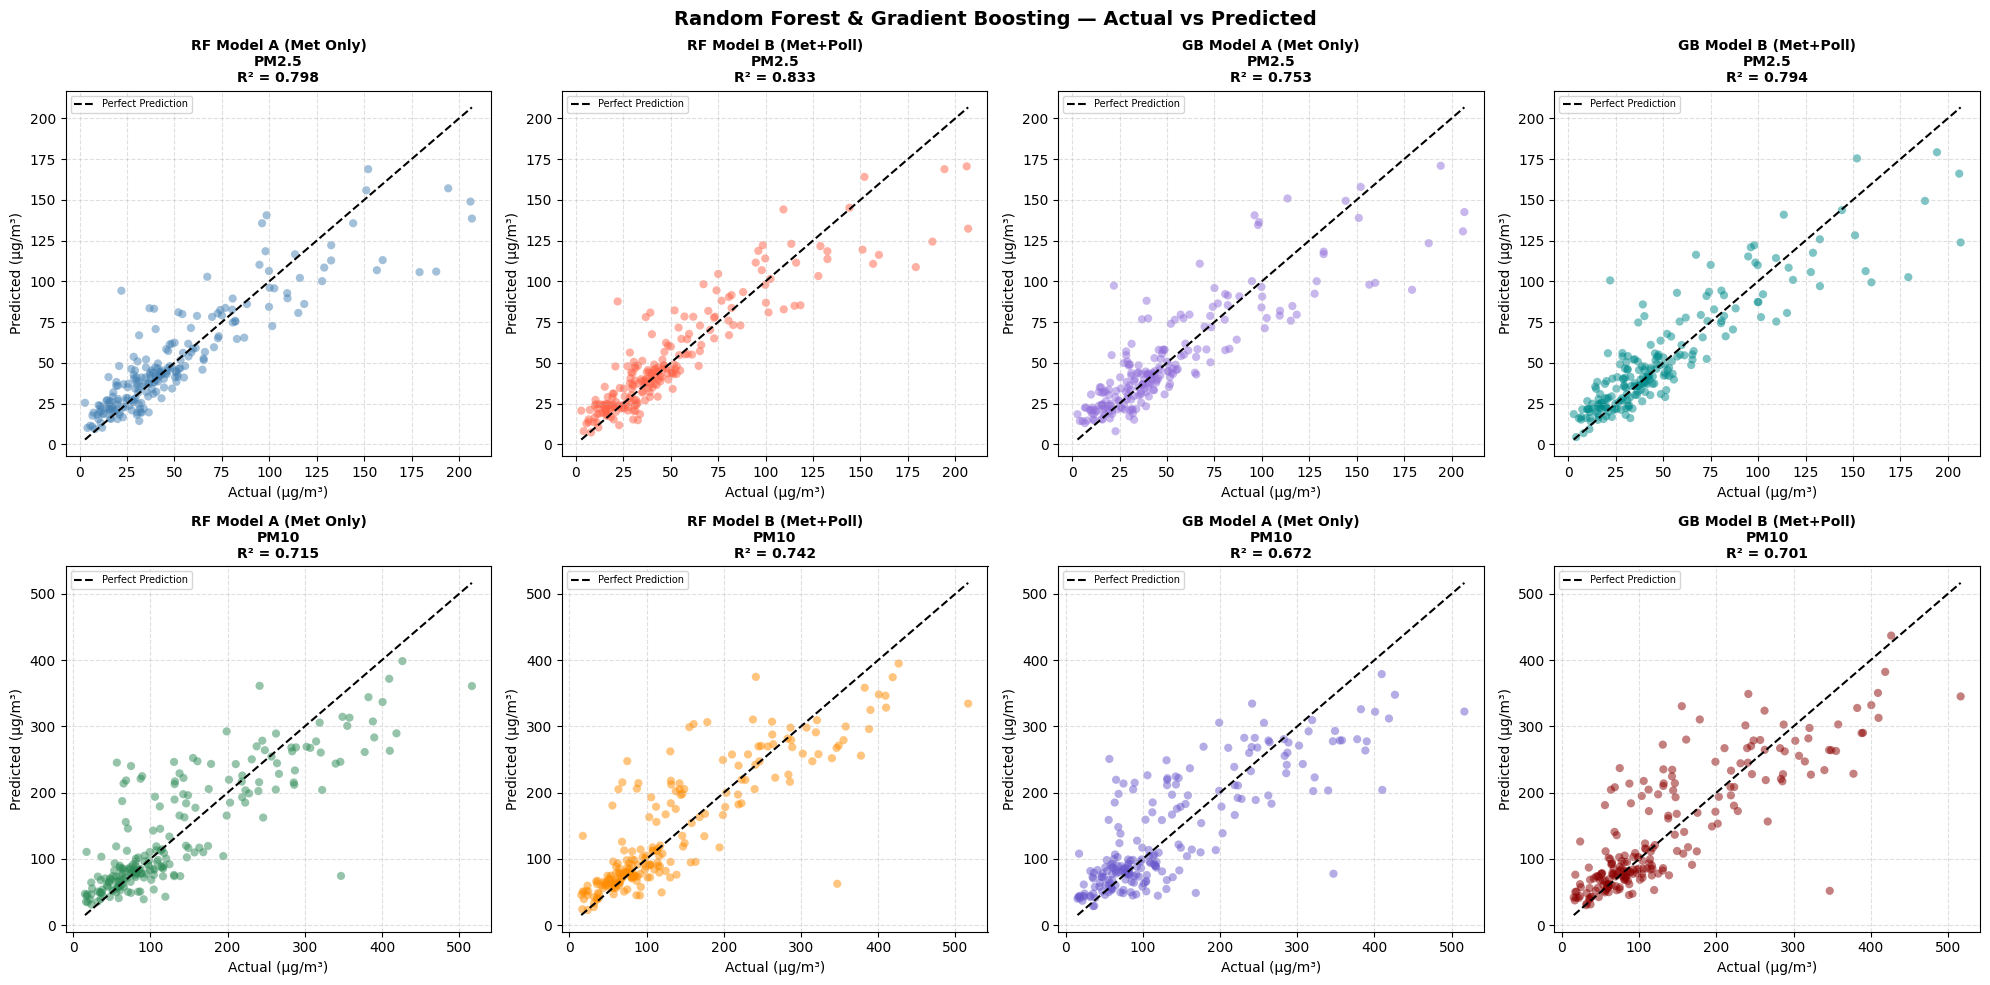

✅ Plot saved!


In [17]:
# ============================================================
# STEP 5C: ACTUAL vs PREDICTED — RF and GB
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

plot_data = [
    # Row 1: PM2.5
    (axes[0,0], y25_test, pred_rf_A_25,  "RF Model A (Met Only)\nPM2.5",      "steelblue"),
    (axes[0,1], y25_test, pred_rf_B_25,  "RF Model B (Met+Poll)\nPM2.5",      "tomato"),
    (axes[0,2], y25_test, pred_gb_A_25,  "GB Model A (Met Only)\nPM2.5",      "mediumpurple"),
    (axes[0,3], y25_test, pred_gb_B_25,  "GB Model B (Met+Poll)\nPM2.5",      "darkcyan"),
    # Row 2: PM10
    (axes[1,0], y10_test, pred_rf_A_10,  "RF Model A (Met Only)\nPM10",       "seagreen"),
    (axes[1,1], y10_test, pred_rf_B_10,  "RF Model B (Met+Poll)\nPM10",       "darkorange"),
    (axes[1,2], y10_test, pred_gb_A_10,  "GB Model A (Met Only)\nPM10",       "slateblue"),
    (axes[1,3], y10_test, pred_gb_B_10,  "GB Model B (Met+Poll)\nPM10",       "darkred"),
]

for ax, y_true, y_pred, title, color in plot_data:
    ax.scatter(y_true, y_pred, alpha=0.5, color=color, edgecolors='none', s=35)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect Prediction')
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f"{title}\nR² = {r2:.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Actual (µg/m³)")
    ax.set_ylabel("Predicted (µg/m³)")
    ax.legend(fontsize=7)
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle("Random Forest & Gradient Boosting — Actual vs Predicted", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_rf_gb_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

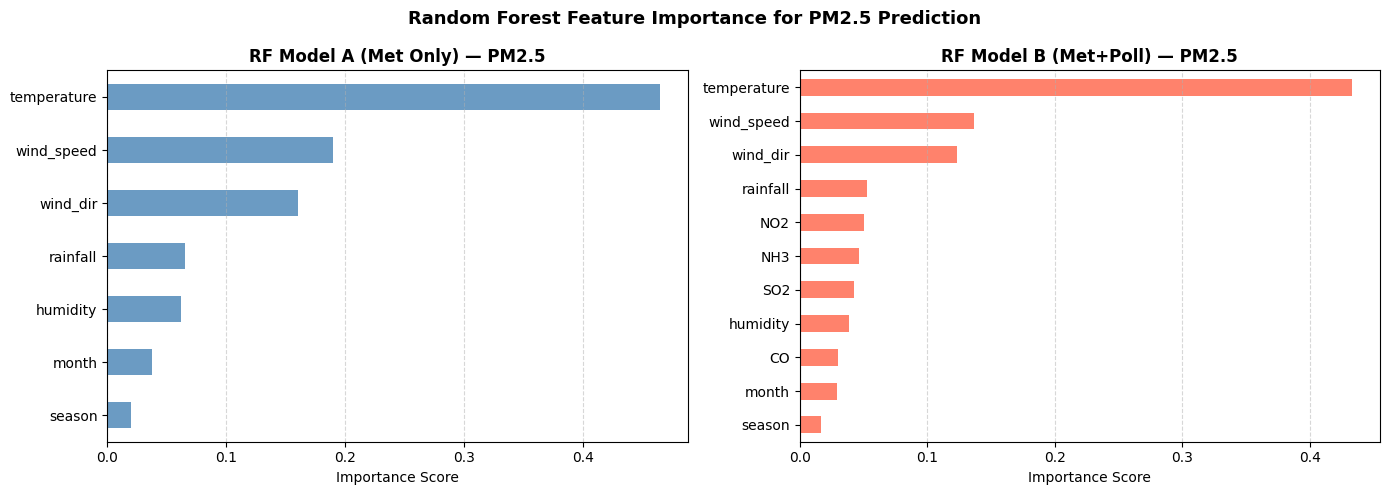

✅ Plot saved!


In [18]:
# ============================================================
# STEP 5D: FEATURE IMPORTANCE — Random Forest
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, features, title, color in [
    (axes[0], rf_A_25, met_features,      "RF Model A (Met Only) — PM2.5",      "steelblue"),
    (axes[1], rf_B_25, met_poll_features, "RF Model B (Met+Poll) — PM2.5",      "tomato"),
]:
    importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
    importance.plot(kind='barh', ax=ax, color=color, alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Importance Score")
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle("Random Forest Feature Importance for PM2.5 Prediction", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

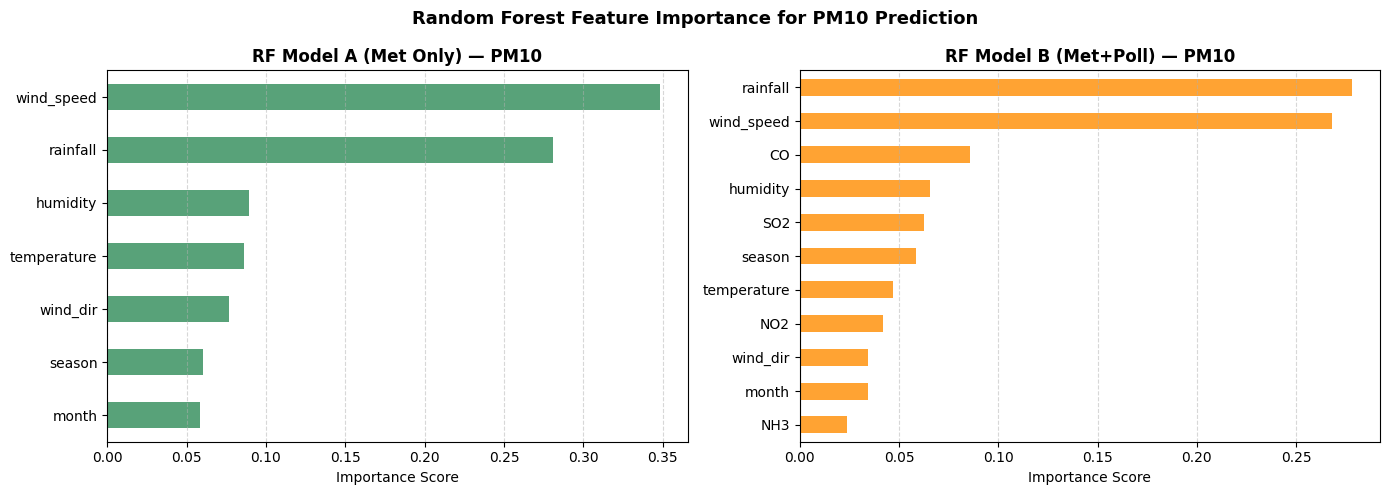

✅ Plot saved!


In [19]:
# ============================================================
# STEP 5E: FEATURE IMPORTANCE — Random Forest for PM10
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, features, title, color in [
    (axes[0], rf_A_10, met_features,      "RF Model A (Met Only) — PM10",   "seagreen"),
    (axes[1], rf_B_10, met_poll_features, "RF Model B (Met+Poll) — PM10",   "darkorange"),
]:
    importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
    importance.plot(kind='barh', ax=ax, color=color, alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Importance Score")
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle("Random Forest Feature Importance for PM10 Prediction", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot9_feature_importance_PM10.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

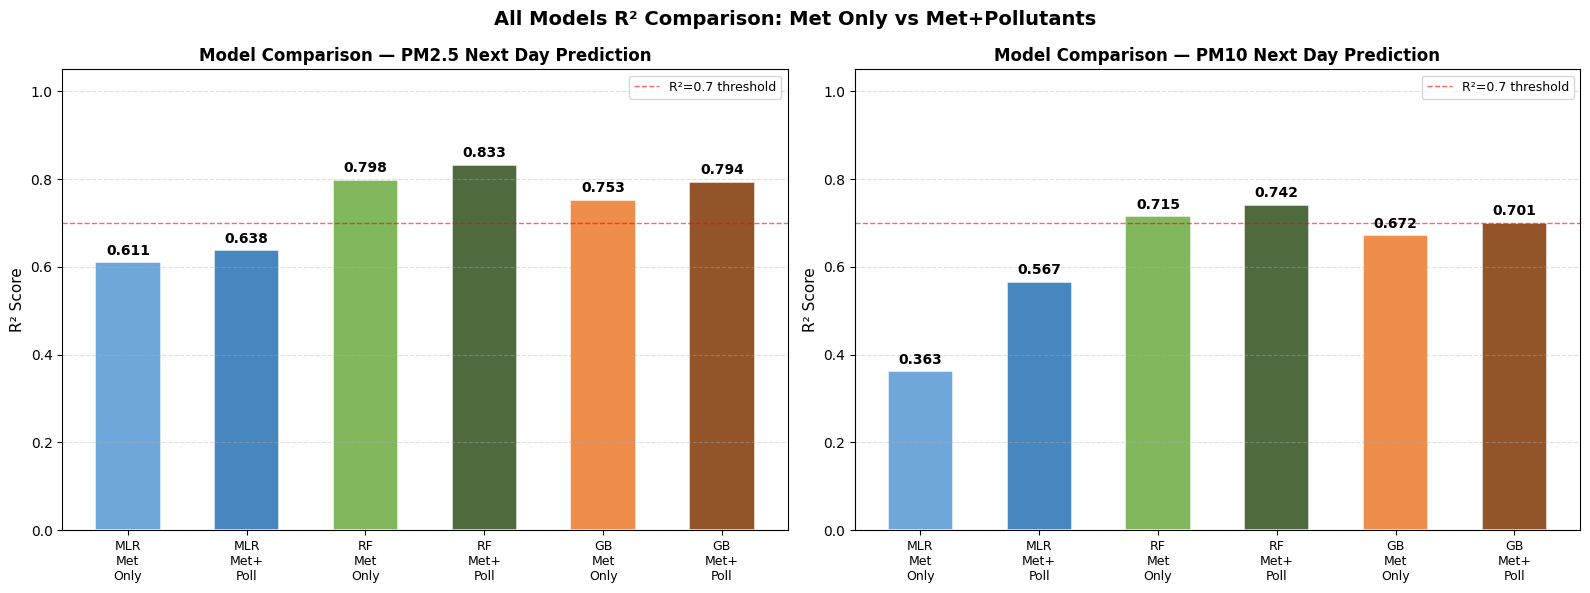

✅ Final comparison chart saved!


In [21]:
# ============================================================
# STEP 6: FINAL MODEL COMPARISON BAR CHART
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models    = ['MLR', 'MLR', 'RF', 'RF', 'GB', 'GB']
feat_sets = ['Met\nOnly', 'Met+\nPoll', 'Met\nOnly', 'Met+\nPoll', 'Met\nOnly', 'Met+\nPoll']
labels    = [f"{m}\n{f}" for m, f in zip(models, feat_sets)]

r2_pm25  = [0.6108, 0.6384, 0.7985, 0.8331, 0.7533, 0.7944]
r2_pm10  = [0.3628, 0.5665, 0.7154, 0.7418, 0.6724, 0.7006]

colors = ['#5B9BD5','#2E75B6', '#70AD47','#375623', '#ED7D31','#843C0C']
x = np.arange(len(labels))
width = 0.55

for ax, r2_vals, target in [(axes[0], r2_pm25, 'PM2.5'), (axes[1], r2_pm10, 'PM10')]:
    bars = ax.bar(x, r2_vals, width=width, color=colors, alpha=0.88, edgecolor='white', linewidth=1.2)
    # Add value labels on top of bars
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('R² Score', fontsize=11)
    ax.set_title(f'Model Comparison — {target} Next Day Prediction', fontsize=12, fontweight='bold')
    ax.axhline(y=0.7, color='red', linestyle='--', linewidth=1, alpha=0.6, label='R²=0.7 threshold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(fontsize=9)

plt.suptitle('All Models R² Comparison: Met Only vs Met+Pollutants', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot10_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final comparison chart saved!")

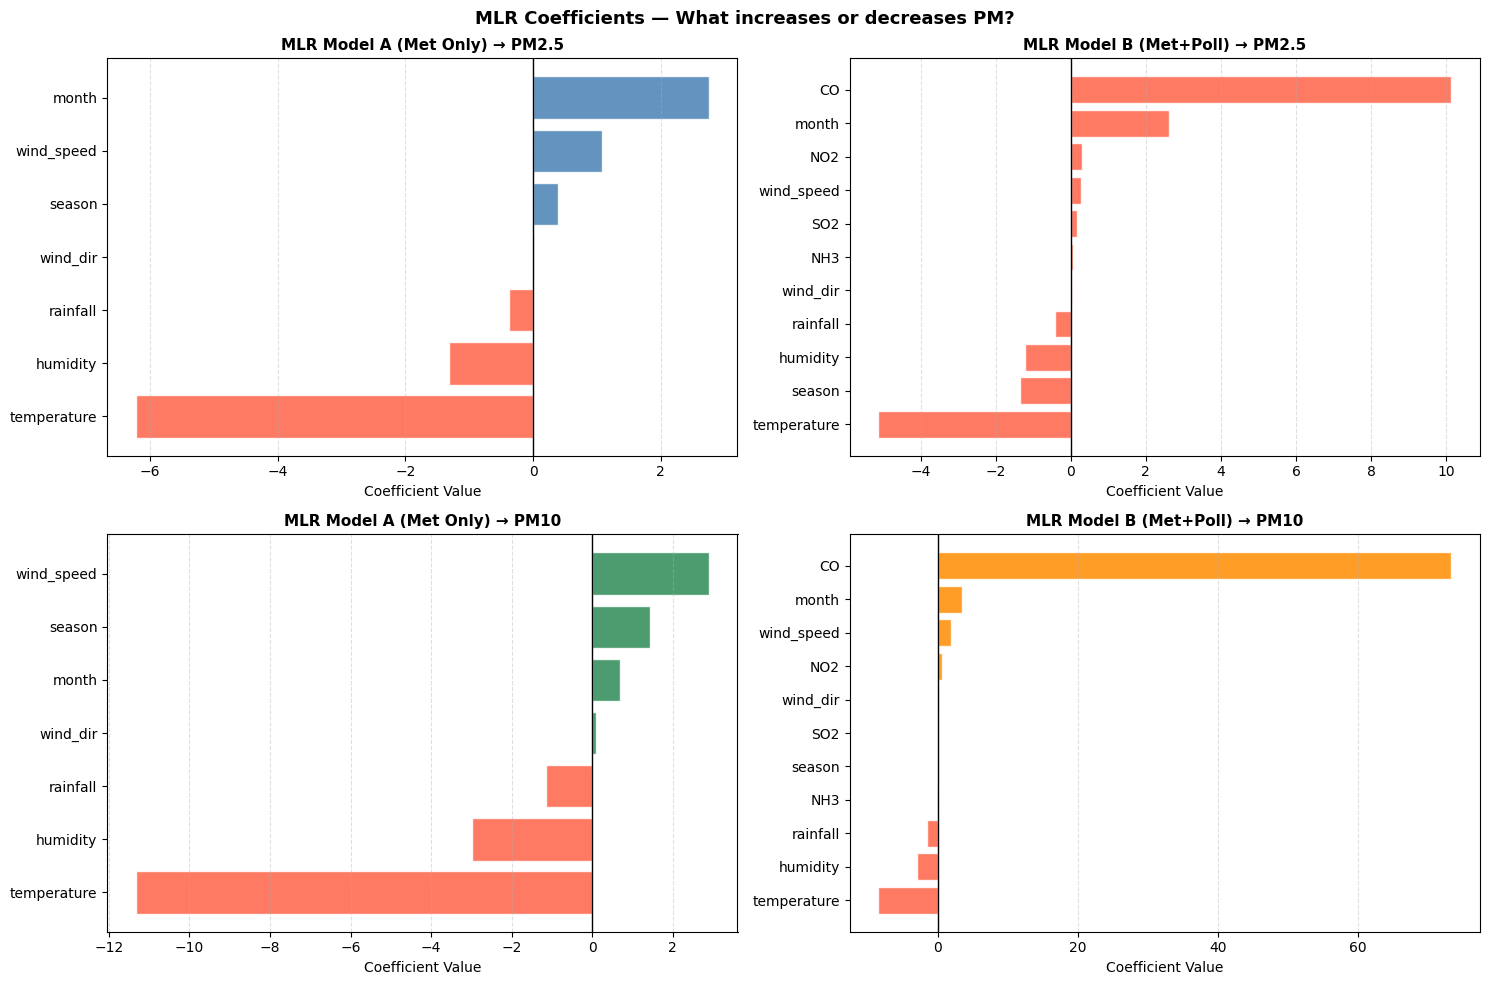

✅ Coefficient chart saved!


In [22]:
# ============================================================
# STEP 6B: VISUALIZE MLR COEFFICIENTS — PM2.5 and PM10
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

coef_data = [
    (axes[0,0], coef_A,   "MLR Model A (Met Only) → PM2.5",   "steelblue"),
    (axes[0,1], coef_B,   "MLR Model B (Met+Poll) → PM2.5",   "tomato"),
    (axes[1,0], coef_A10, "MLR Model A (Met Only) → PM10",    "seagreen"),
    (axes[1,1], coef_B10, "MLR Model B (Met+Poll) → PM10",    "darkorange"),
]

for ax, coef_df, title, color in coef_data:
    sorted_df = coef_df.sort_values('Coefficient')
    bar_colors = ['tomato' if v < 0 else color for v in sorted_df['Coefficient']]
    ax.barh(sorted_df['Feature'], sorted_df['Coefficient'],
            color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Coefficient Value')
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('MLR Coefficients — What increases or decreases PM?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot11_mlr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Coefficient chart saved!")

In [23]:
# ============================================================
# STEP 6C: CLEAN FINAL SUMMARY TABLE
# ============================================================

print("\n" + "=" * 65)
print("        FINAL RESULTS SUMMARY — YOUR PROJECT")
print("=" * 65)
print(f"{'Model':<20} {'Features':<16} {'Target':<8} {'R²':>6} {'MAE':>7} {'RMSE':>7}")
print("-" * 65)

for _, row in results_df.iterrows():
    print(f"{row['Model']:<20} {row['Features']:<16} {row['Target']:<8} "
          f"{row['R²']:>6.4f} {row['MAE']:>7.2f} {row['RMSE']:>7.2f}")

print("=" * 65)
print("\n🏆 Best model overall : Random Forest — Met+Pollutants")
print("   PM2.5 → R²=0.8331, MAE=10.89, RMSE=16.20")
print("   PM10  → R²=0.7418, MAE=34.73, RMSE=52.91")
print("\n📌 Key findings:")
print("   1. Met+Pollutants always beats Met Only → pollutants carry extra signal")
print("   2. RF > GB > MLR for all cases → non-linear models fit PM data better")
print("   3. PM2.5 is predicted better than PM10 (heavier particles = more random)")
print("   4. Temperature is top feature for PM2.5 (seasonal effect)")
print("   5. Wind speed is top feature for PM10 (mechanical dust lifting)")


        FINAL RESULTS SUMMARY — YOUR PROJECT
Model                Features         Target       R²     MAE    RMSE
-----------------------------------------------------------------
MLR                  Met Only         PM2.5    0.6108   18.15   24.73
MLR                  Met+Pollutants   PM2.5    0.6384   17.75   23.84
Random Forest        Met Only         PM2.5    0.7985   11.73   17.80
Random Forest        Met+Pollutants   PM2.5    0.8331   10.89   16.20
Gradient Boosting    Met Only         PM2.5    0.7533   13.36   19.69
Gradient Boosting    Met+Pollutants   PM2.5    0.7944   12.24   17.97
MLR                  Met Only         PM10     0.3628   62.56   83.12
MLR                  Met+Pollutants   PM10     0.5665   51.67   68.56
Random Forest        Met Only         PM10     0.7154   38.06   55.55
Random Forest        Met+Pollutants   PM10     0.7418   34.73   52.91
Gradient Boosting    Met Only         PM10     0.6724   42.54   59.60
Gradient Boosting    Met+Pollutants   PM10     0

/tmp/ipykernel_1543/1491600974.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(season_groups_25, labels=season_order, patch_artist=True,
/tmp/ipykernel_1543/1491600974.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(season_groups_10, labels=season_order, patch_artist=True,


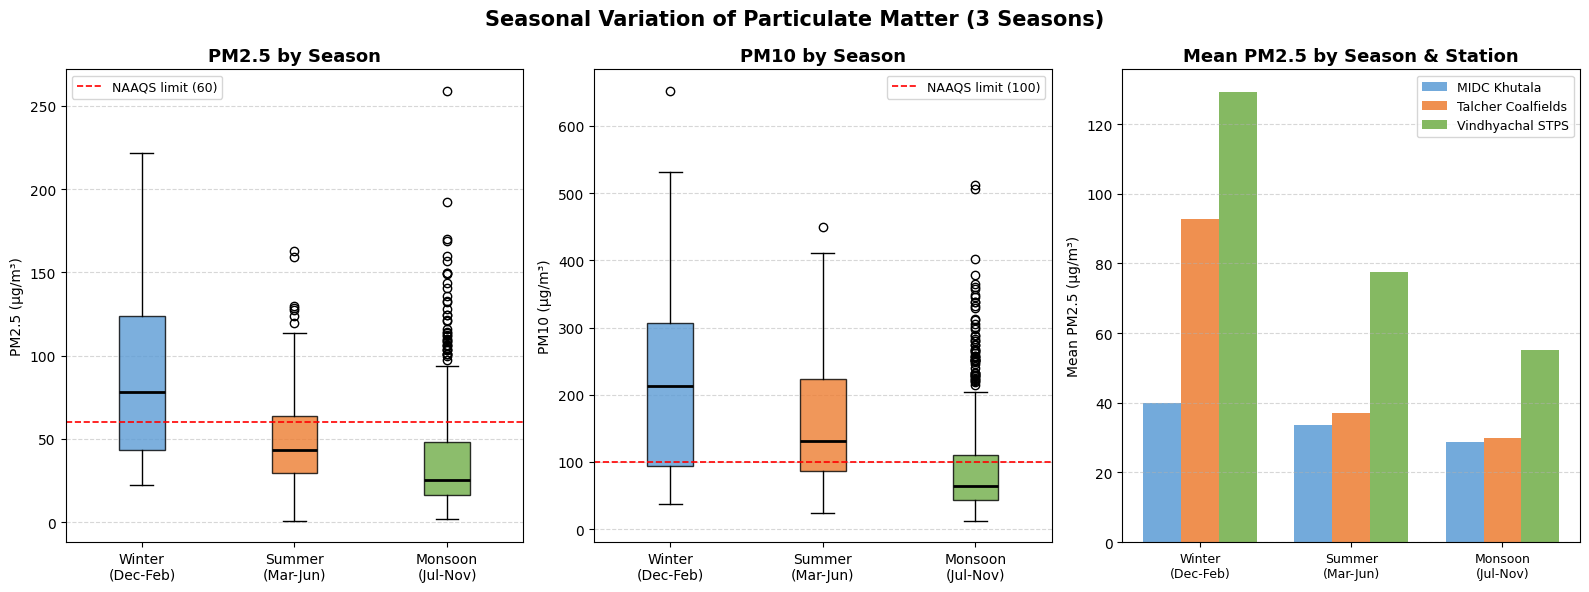

SEASONAL AVERAGE VALUES — ALL STATIONS COMBINED
                    PM2.5    PM10  temperature  humidity  wind_speed  rainfall
season_label                                                                  
Winter\n(Dec-Feb)   87.30  215.32        20.73     66.48        5.65      0.30
Summer\n(Mar-Jun)   49.56  163.46        31.19     47.26        8.25      1.11
Monsoon\n(Jul-Nov)  38.59   96.23        26.46     81.16        6.06      6.80

📌 Interpretation:
   Winter  → Highest PM  (cold, dry, no rain, dust trapped near ground)
   Summer  → Moderate PM (dry but wind helps disperse some dust)
   Monsoon → Lowest PM   (rain washes dust down, humidity is high)


In [24]:
# ============================================================
# SEASONAL VARIATION — 3 SEASONS ONLY
# ============================================================

# Map months to 3 seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter\n(Dec-Feb)'
    elif month in [3, 4, 5, 6]:
        return 'Summer\n(Mar-Jun)'
    else:
        return 'Monsoon\n(Jul-Nov)'

df['season_label'] = df['month'].apply(get_season)
season_order = ['Winter\n(Dec-Feb)', 'Summer\n(Mar-Jun)', 'Monsoon\n(Jul-Nov)']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
box_colors = ['#5B9BD5', '#ED7D31', '#70AD47']

# ---- Plot 1: PM2.5 Boxplot ----
season_groups_25 = [df[df['season_label']==s]['PM2.5'].dropna() for s in season_order]
bp1 = axes[0].boxplot(season_groups_25, labels=season_order, patch_artist=True,
                       medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp1['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title('PM2.5 by Season', fontsize=13, fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].axhline(y=60, color='red', linestyle='--', linewidth=1.2, label='NAAQS limit (60)')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ---- Plot 2: PM10 Boxplot ----
season_groups_10 = [df[df['season_label']==s]['PM10'].dropna() for s in season_order]
bp2 = axes[1].boxplot(season_groups_10, labels=season_order, patch_artist=True,
                       medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title('PM10 by Season', fontsize=13, fontweight='bold')
axes[1].set_ylabel('PM10 (µg/m³)')
axes[1].axhline(y=100, color='red', linestyle='--', linewidth=1.2, label='NAAQS limit (100)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# ---- Plot 3: Mean PM2.5 by Season & Station ----
season_station = df.groupby(['season_label', 'station'])[['PM2.5','PM10']].mean().reset_index()
station_short  = {s: s.split(',')[0] for s in df['station'].unique()}
season_station['station_short'] = season_station['station'].map(station_short)

x      = np.arange(len(season_order))
width  = 0.25
stations_list = season_station['station_short'].unique()

for i, (st, color) in enumerate(zip(stations_list, box_colors)):
    vals = []
    for s in season_order:
        row = season_station[(season_station['season_label']==s) &
                             (season_station['station_short']==st)]['PM2.5']
        vals.append(row.values[0] if len(row) > 0 else 0)
    axes[2].bar(x + i*width, vals, width=width, label=st, color=color, alpha=0.85)

axes[2].set_xticks(x + width)
axes[2].set_xticklabels(season_order, fontsize=9)
axes[2].set_title('Mean PM2.5 by Season & Station', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Mean PM2.5 (µg/m³)')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Seasonal Variation of Particulate Matter (3 Seasons)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot12_seasonal_variation.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Stats Table ----
print("=" * 65)
print("SEASONAL AVERAGE VALUES — ALL STATIONS COMBINED")
print("=" * 65)
seasonal_stats = df.groupby('season_label')[['PM2.5','PM10',
                 'temperature','humidity','wind_speed','rainfall']].mean().round(2)
seasonal_stats = seasonal_stats.reindex(season_order)
print(seasonal_stats.to_string())
print("\n📌 Interpretation:")
print("   Winter  → Highest PM  (cold, dry, no rain, dust trapped near ground)")
print("   Summer  → Moderate PM (dry but wind helps disperse some dust)")
print("   Monsoon → Lowest PM   (rain washes dust down, humidity is high)")

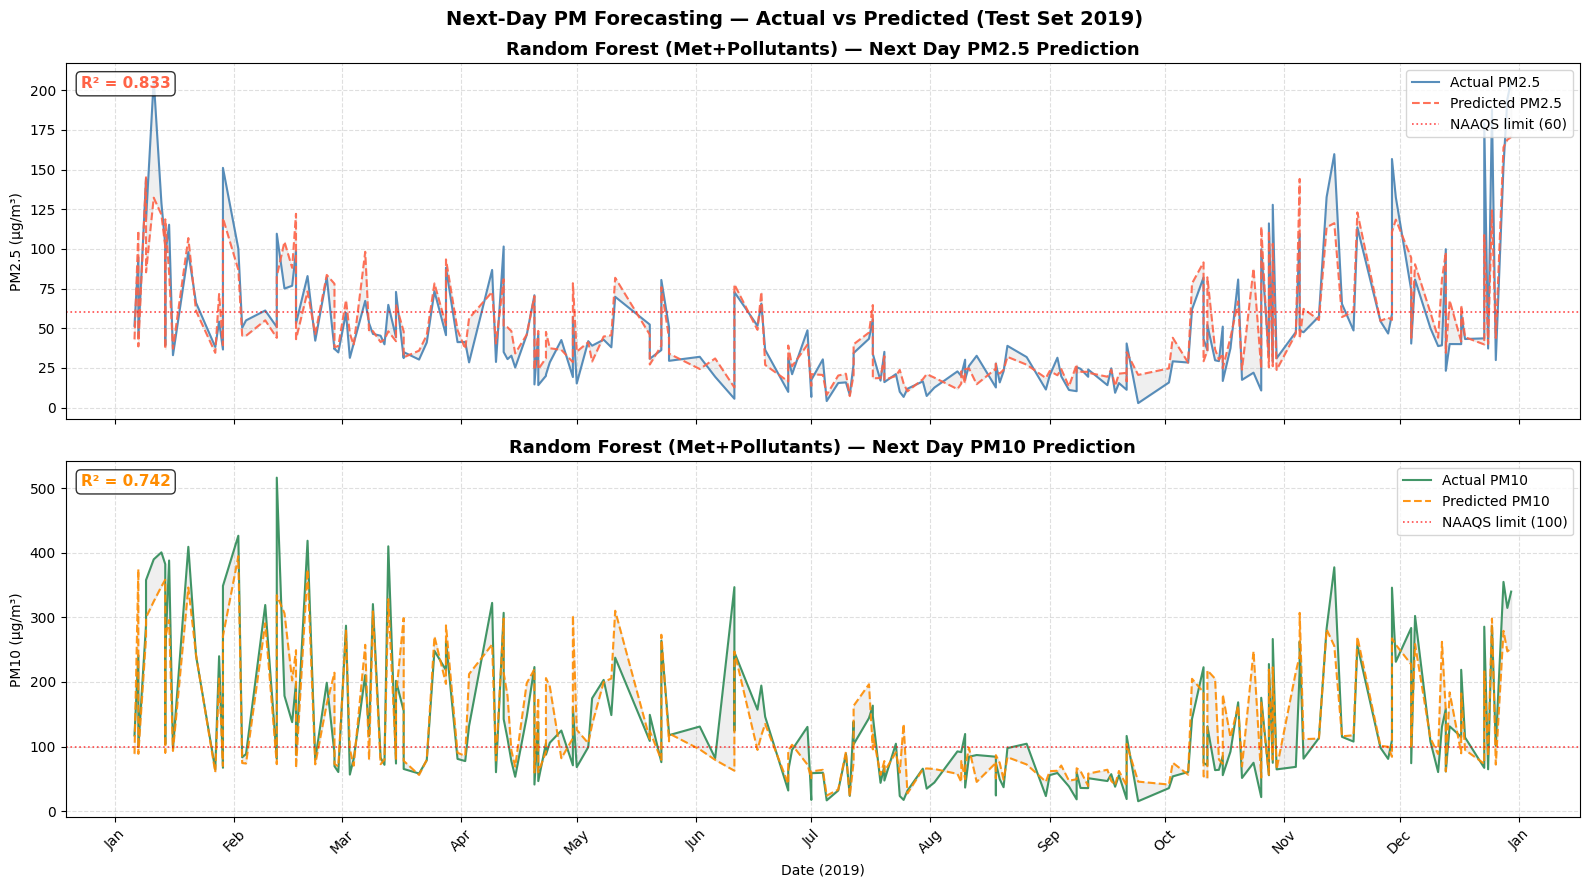

✅ Time series plot saved!


In [25]:
# ============================================================
# STEP 7: TIME SERIES — ACTUAL vs PREDICTED
# Best Model: Random Forest Met+Pollutants
# ============================================================

# Get the test set dates for plotting
test_indices = X_B_test.index
test_dates   = df.loc[test_indices, 'date']

# Sort by date for clean time series
sort_order   = test_dates.argsort()
dates_sorted = test_dates.iloc[sort_order]
actual_25    = y25_test.iloc[sort_order]
pred_25      = pred_rf_B_25[sort_order]
actual_10    = y10_test.iloc[sort_order]
pred_10      = pred_rf_B_10[sort_order]

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# ---- PM2.5 ----
axes[0].plot(dates_sorted, actual_25, color='steelblue',  linewidth=1.5,
             label='Actual PM2.5',    alpha=0.9)
axes[0].plot(dates_sorted, pred_25,   color='tomato',     linewidth=1.5,
             label='Predicted PM2.5', alpha=0.9, linestyle='--')
axes[0].fill_between(dates_sorted, actual_25, pred_25, alpha=0.12, color='grey')
axes[0].axhline(y=60, color='red', linestyle=':', linewidth=1.2, alpha=0.7, label='NAAQS limit (60)')
axes[0].set_title('Random Forest (Met+Pollutants) — Next Day PM2.5 Prediction',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend(loc='upper right', fontsize=10)
axes[0].grid(linestyle='--', alpha=0.4)
r2_25 = r2_score(actual_25, pred_25)
axes[0].text(0.01, 0.93, f'R² = {r2_25:.3f}', transform=axes[0].transAxes,
             fontsize=11, fontweight='bold', color='tomato',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ---- PM10 ----
axes[1].plot(dates_sorted, actual_10, color='seagreen',    linewidth=1.5,
             label='Actual PM10',    alpha=0.9)
axes[1].plot(dates_sorted, pred_10,   color='darkorange',  linewidth=1.5,
             label='Predicted PM10', alpha=0.9, linestyle='--')
axes[1].fill_between(dates_sorted, actual_10, pred_10, alpha=0.12, color='grey')
axes[1].axhline(y=100, color='red', linestyle=':', linewidth=1.2, alpha=0.7, label='NAAQS limit (100)')
axes[1].set_title('Random Forest (Met+Pollutants) — Next Day PM10 Prediction',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('PM10 (µg/m³)')
axes[1].set_xlabel('Date (2019)')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(linestyle='--', alpha=0.4)
r2_10 = r2_score(actual_10, pred_10)
axes[1].text(0.01, 0.93, f'R² = {r2_10:.3f}', transform=axes[1].transAxes,
             fontsize=11, fontweight='bold', color='darkorange',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

import matplotlib.dates as mdates
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.suptitle('Next-Day PM Forecasting — Actual vs Predicted (Test Set 2019)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot13_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Time series plot saved!")